## Topic analysis

### 0. Common setup and data loading

In [16]:
import pandas as pd
import re

csv_path = "unified_sentiment_topic_sentences.csv"

df = pd.read_csv(csv_path)

df = df.dropna(subset=["text", "topic"])
df = df[df["topic"].isin(["book", "movie", "restaurant"])]

df["text"] = df["text"].astype(str).str.lower()
df["text"] = df["text"].apply(lambda t: re.sub(r"[^\w\s]", " ", t))
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

df["word_count"] = df["text"].str.split().str.len()
df = df[df["word_count"] >= 20]

df = df.drop(columns=["word_count"])

print("Remaining rows:", len(df))
print(df["topic"].value_counts())
df.sample(5)

Remaining rows: 75394
topic
movie         30430
book          23805
restaurant    21159
Name: count, dtype: int64


,text,sentiment,topic
29744,if only jean claude weren t getting so old and...,negative,movie
192527,often times we forget caroline is speaking in ...,positive,book
45906,this is a great possibility to create a magnif...,positive,movie
87801,i m not going to give it a thumbs down and wil...,neutral,restaurant
165139,awful got a taco salad had refried beans in it...,negative,restaurant


### 1. LDA topic model

#### 1.1 Imports and preprocessing

In [17]:
import numpy as np
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt


texts = df["text"].astype(str).tolist()

vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print("Document-term matrix shape:", X.shape)

Document-term matrix shape: (75394, 5000)


#### 1.2 Fitting LDA

In [18]:
n_topics = 3
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="online",
    learning_offset=50.,
    random_state=0,
)
lda.fit(X)

def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join(feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]))
        print()

print_top_words(lda, feature_names, n_top_words=15)

Topic #0:
book read quot story film books characters reading like movie novel good character great author

Topic #1:
food place good just like time didn order ve got really don great came service

Topic #2:
life man family old new young help live world years love people war woman wife



#### 1.3 Getting topic distribution per document and assign dominant topic

In [19]:
doc_topic_dist = lda.transform(X)

lda_topic_labels = doc_topic_dist.argmax(axis=1)

df_lda = df.copy()
df_lda["lda_topic"] = lda_topic_labels

print(df_lda[["text", "topic", "lda_topic"]].sample(10))

cm = pd.crosstab(df_lda["topic"], df_lda["lda_topic"])
print(cm)

                                                     text       topic  \
151178  it came out to about 50 dollars with tax and t...  restaurant   
211615  i d been told that it was an exciting story so...        book   
221059  second time around for this great story althou...        book   
78961   the burrito came back partly eaten by the chef...  restaurant   
36538   tom starts an affair with larry s wife tish an...       movie   
8805    de bont has a style of filmmaking so out of li...       movie   
136562  will definitely return to try some of the othe...  restaurant   
88481   from classics such as the fat steve s and glaz...  restaurant   
141835  service was good prices were reasonable and th...  restaurant   
41076   com an online convenience store stocked with i...       movie   

        lda_topic  
151178          1  
211615          0  
221059          0  
78961           1  
36538           2  
8805            0  
136562          1  
88481           1  
141835          

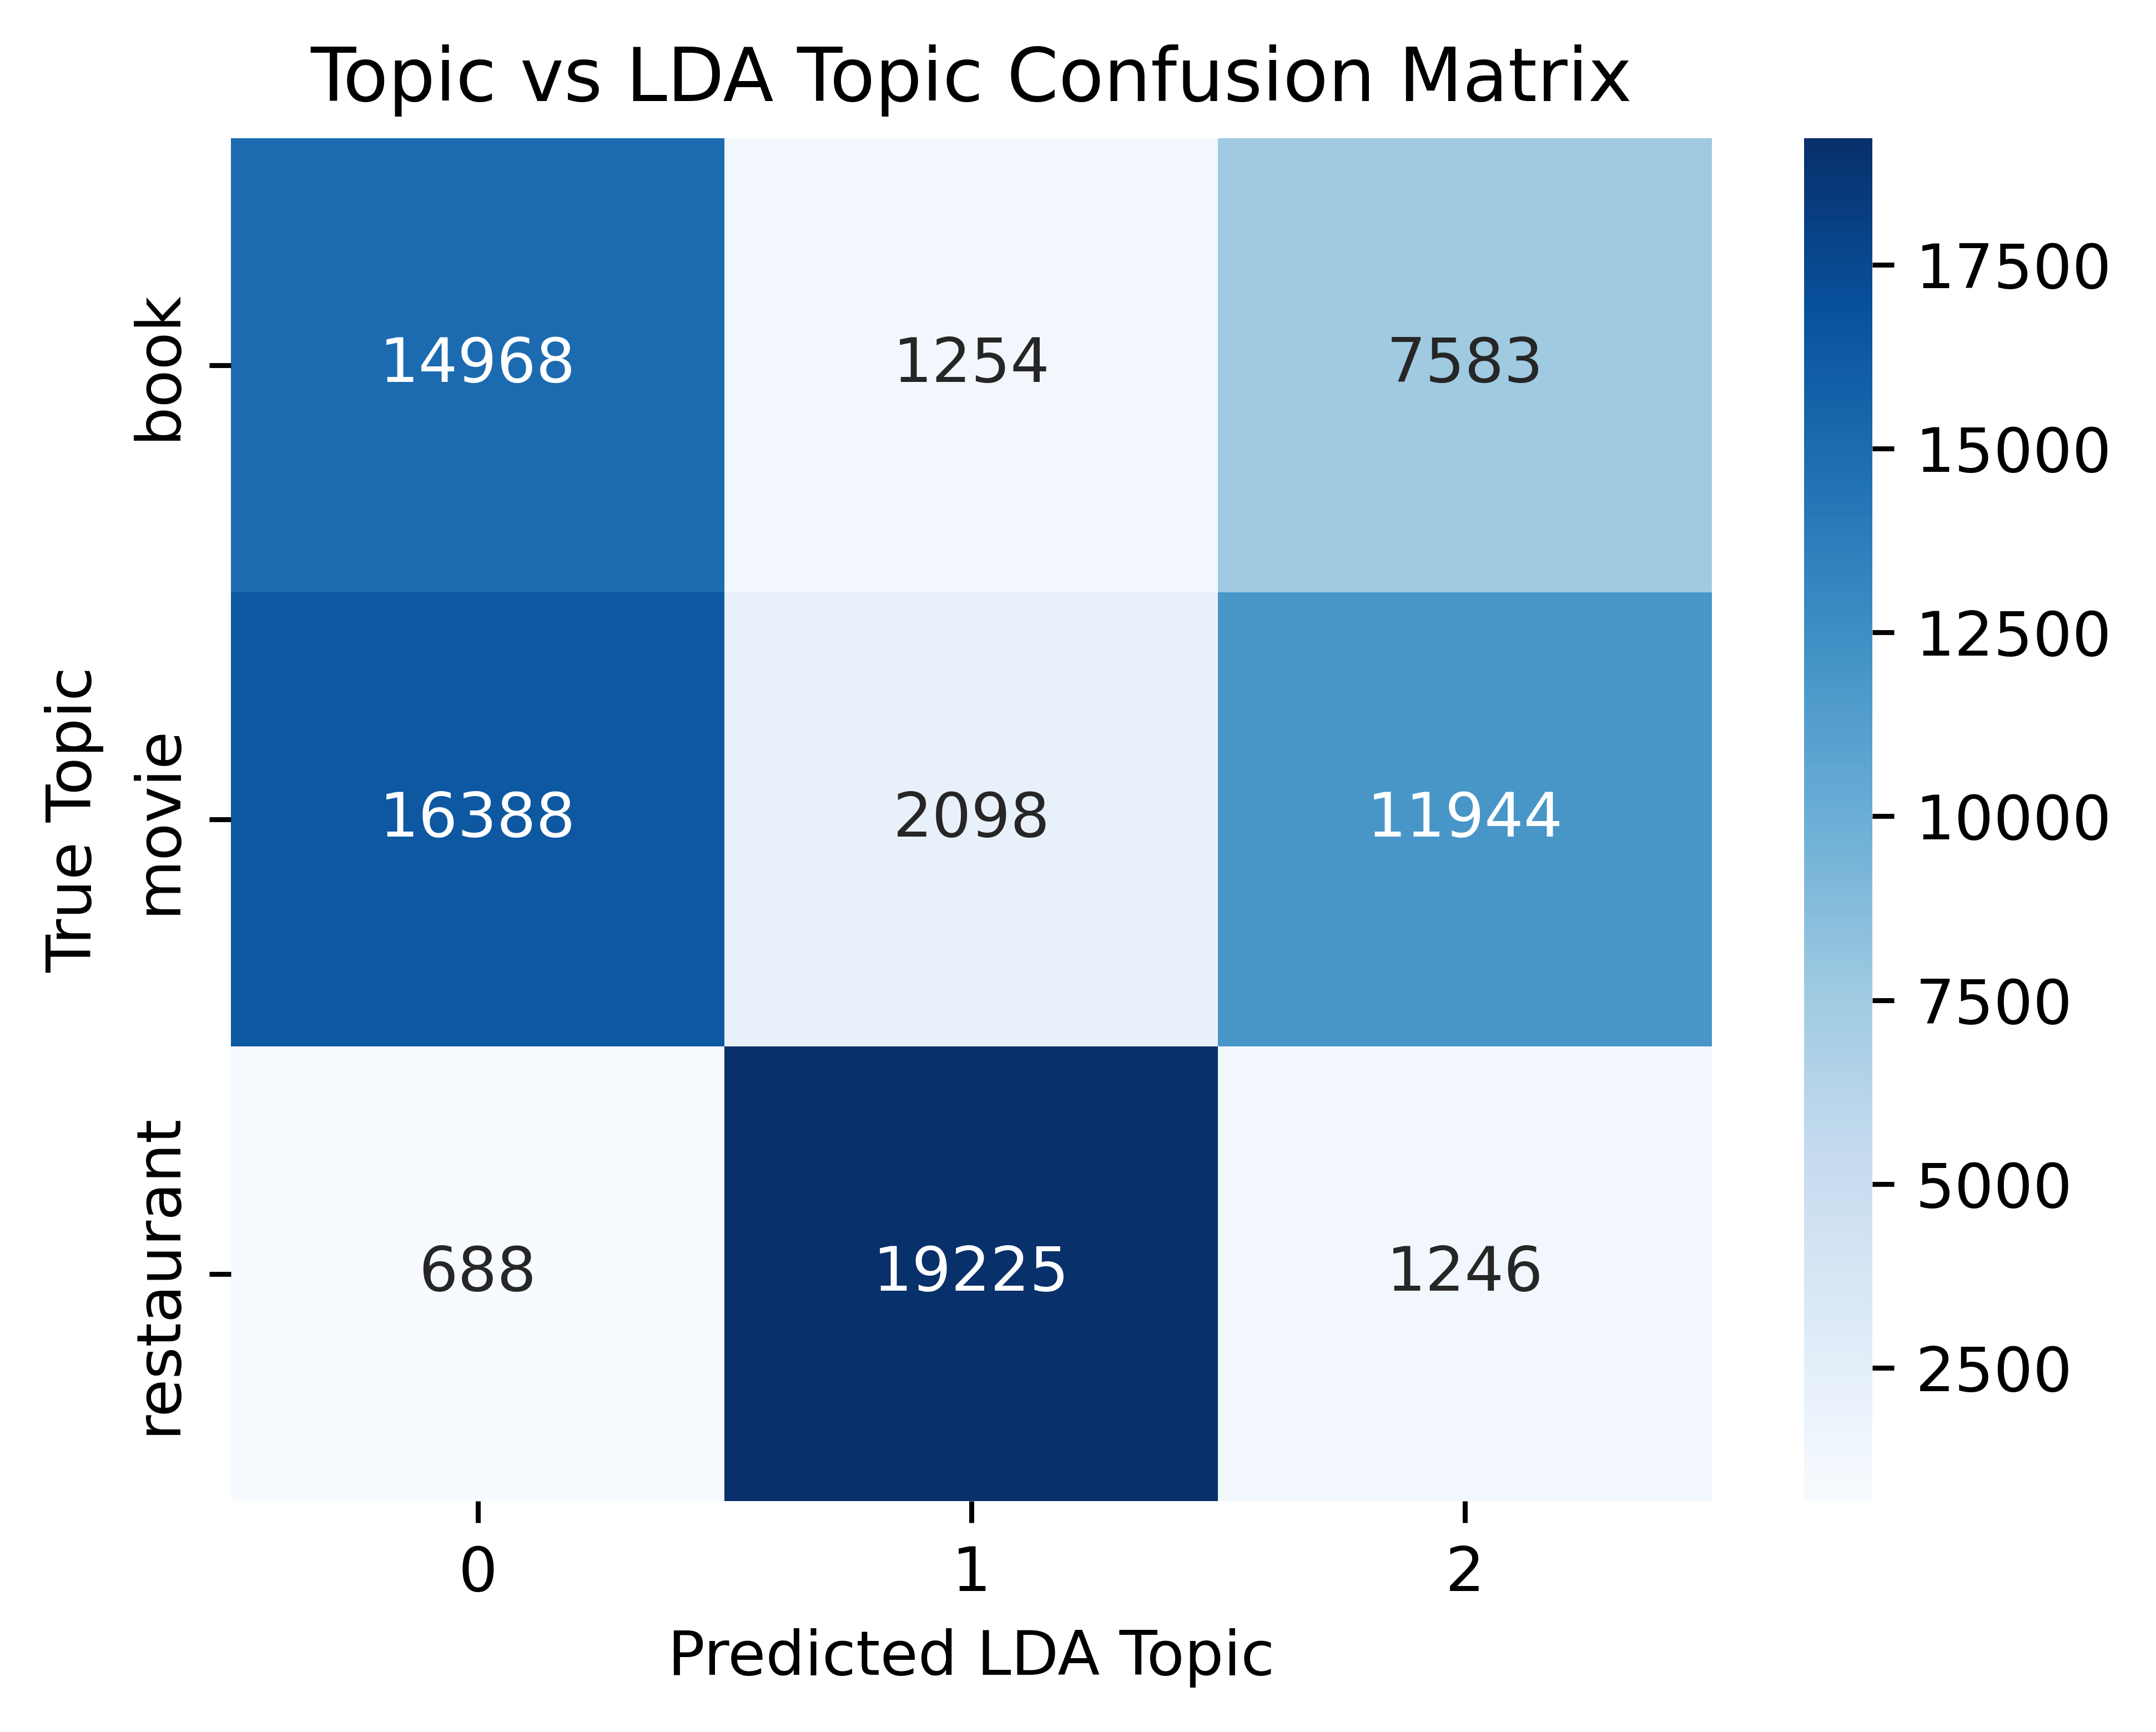

In [15]:
import seaborn as sns

plt.figure(figsize=(5, 4), dpi=800)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Topic vs LDA Topic Confusion Matrix")
plt.xlabel("Predicted LDA Topic")
plt.ylabel("True Topic")
plt.tight_layout()
plt.show()

### 2. BERT topic classifier

In [22]:
!pip install simpletransformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.5/332.5 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.5 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=acb91abd602f71525923ba583edbcb0c8b2f4d21a7127e20d600ddd25d3ee57f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [23]:
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sn

#### 2.1 Preparing train/dev/test splits

In [33]:
label_map = {"book": 0, "movie": 2, "restaurant": 1}
inverse_label_map = {v: k for k, v in label_map.items()}

df_sup = df.copy()
df_sup["labels"] = df_sup["topic"].map(label_map)

df_sup = df_sup.dropna(subset=["text", "labels"])

train_dev, test = train_test_split(
    df_sup,
    test_size=0.2,
    random_state=42,
    stratify=df_sup[["labels"]]
)

train, dev = train_test_split(
    train_dev,
    test_size=0.1,
    random_state=42,
    stratify=train_dev[["labels"]]
)

print("Train size:", len(train))
print("Dev size:", len(dev))
print("Test size:", len(test))

print("Train label distribution:")
print(train["labels"].value_counts())

print("Dev label distribution:")
print(dev["labels"].value_counts())

print("Test label distribution:")
print(test["labels"].value_counts())

train = train[["text", "labels"]].reset_index(drop=True)
dev = dev[["text", "labels"]].reset_index(drop=True)
test = test[["text", "labels"]].reset_index(drop=True)

Train size: 54283
Dev size: 6032
Test size: 15079
Train label distribution:
labels
2    21909
0    17140
1    15234
Name: count, dtype: int64
Dev label distribution:
labels
2    2435
0    1904
1    1693
Name: count, dtype: int64
Test label distribution:
labels
2    6086
0    4761
1    4232
Name: count, dtype: int64


#### 2.2 Configuring BERT model

In [ ]:
model_args = ClassificationArgs()

model_args.overwrite_output_dir = True
model_args.evaluate_during_training = True

model_args.num_train_epochs = 3
model_args.train_batch_size = 64
model_args.learning_rate = 4e-6
model_args.max_seq_length = 128

model_args.use_early_stopping = True
model_args.early_stopping_delta = 0.01
model_args.early_stopping_metric = "eval_loss"
model_args.early_stopping_metric_minimize = True
model_args.early_stopping_patience = 2
model_args.evaluate_during_training_steps = 256

steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print("Each epoch will have {:,} steps.".format(steps_per_epoch))

Each epoch will have 849 steps.


#### 2.4 Initializing BERT classification model

In [ ]:
model = ClassificationModel(
    "bert",
    "bert-base-cased",
    num_labels=3,
    args=model_args,
    use_cuda=True
)

print(str(model.args).replace(",", "\n"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 dataset_cache_dir=None
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=2
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=256
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=True
 gradient_accumulation_steps=1
 learning_rate=4e-06
 local_rank=-1
 logging_steps=50
 loss_type=None


#### 2.5 Training model with dev set for evaluation

In [ ]:
model.train_model(
    train,
    eval_df=dev
)

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


  0%|          | 0/108 [00:00<?, ?it/s]

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 3:   0%|          | 0/849 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(2048,
 defaultdict(list,
             {'global_step': [256,
               512,
               768,
               849,
               1024,
               1280,
               1536,
               1698,
               1792,
               2048],
              'train_loss': [0.3477168083190918,
               0.2374042272567749,
               0.17256009578704834,
               0.18828131258487701,
               0.1678309440612793,
               0.15501165390014648,
               0.16417193412780762,
               0.05141899734735489,
               0.19237592816352844,
               0.08741319179534912],
              'mcc': [np.float64(0.8481253528860622),
               np.float64(0.866479515960515),
               np.float64(0.8750159732721424),
               np.float64(0.8761359384008465),
               np.float64(0.879742653388383),
               np.float64(0.8809170171139536),
               np.float64(0.8853862785771507),
               np.float64(0.885297729342442),


#### 2.6 Evaluating on dev set

In [ ]:
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

  0%|          | 0/12 [00:00<?, ?it/s]

Running Evaluation:   0%|          | 0/61 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


{'mcc': np.float64(0.8873393542386137), 'eval_loss': 0.19097257503232018}

#### 2.7 Predicting on test set

In [ ]:
predicted_labels, probabilities = model.predict(test["text"].tolist())
test["predicted"] = predicted_labels

print(test.head())

  0%|          | 0/30 [00:00<?, ?it/s]

Predicting:   0%|          | 0/151 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


                                                text  labels  predicted
0  what makes this film different than the others...       2          2
1  visually star wars episode i the phantom menac...       2          2
2  they lightened it up a bit and it is more welc...       1          1
3  any architect landscape architect or urban des...       0          0
4  they have a fun tuesday night kids theme 1 99 ...       1          1


#### 2.8 Classification report and confusion matrix

              precision    recall  f1-score   support

           0      0.914     0.861     0.886      4761
           1      0.973     0.979     0.976      4232
           2      0.896     0.932     0.914      6086

    accuracy                          0.923     15079
   macro avg      0.927     0.924     0.925     15079
weighted avg      0.923     0.923     0.923     15079



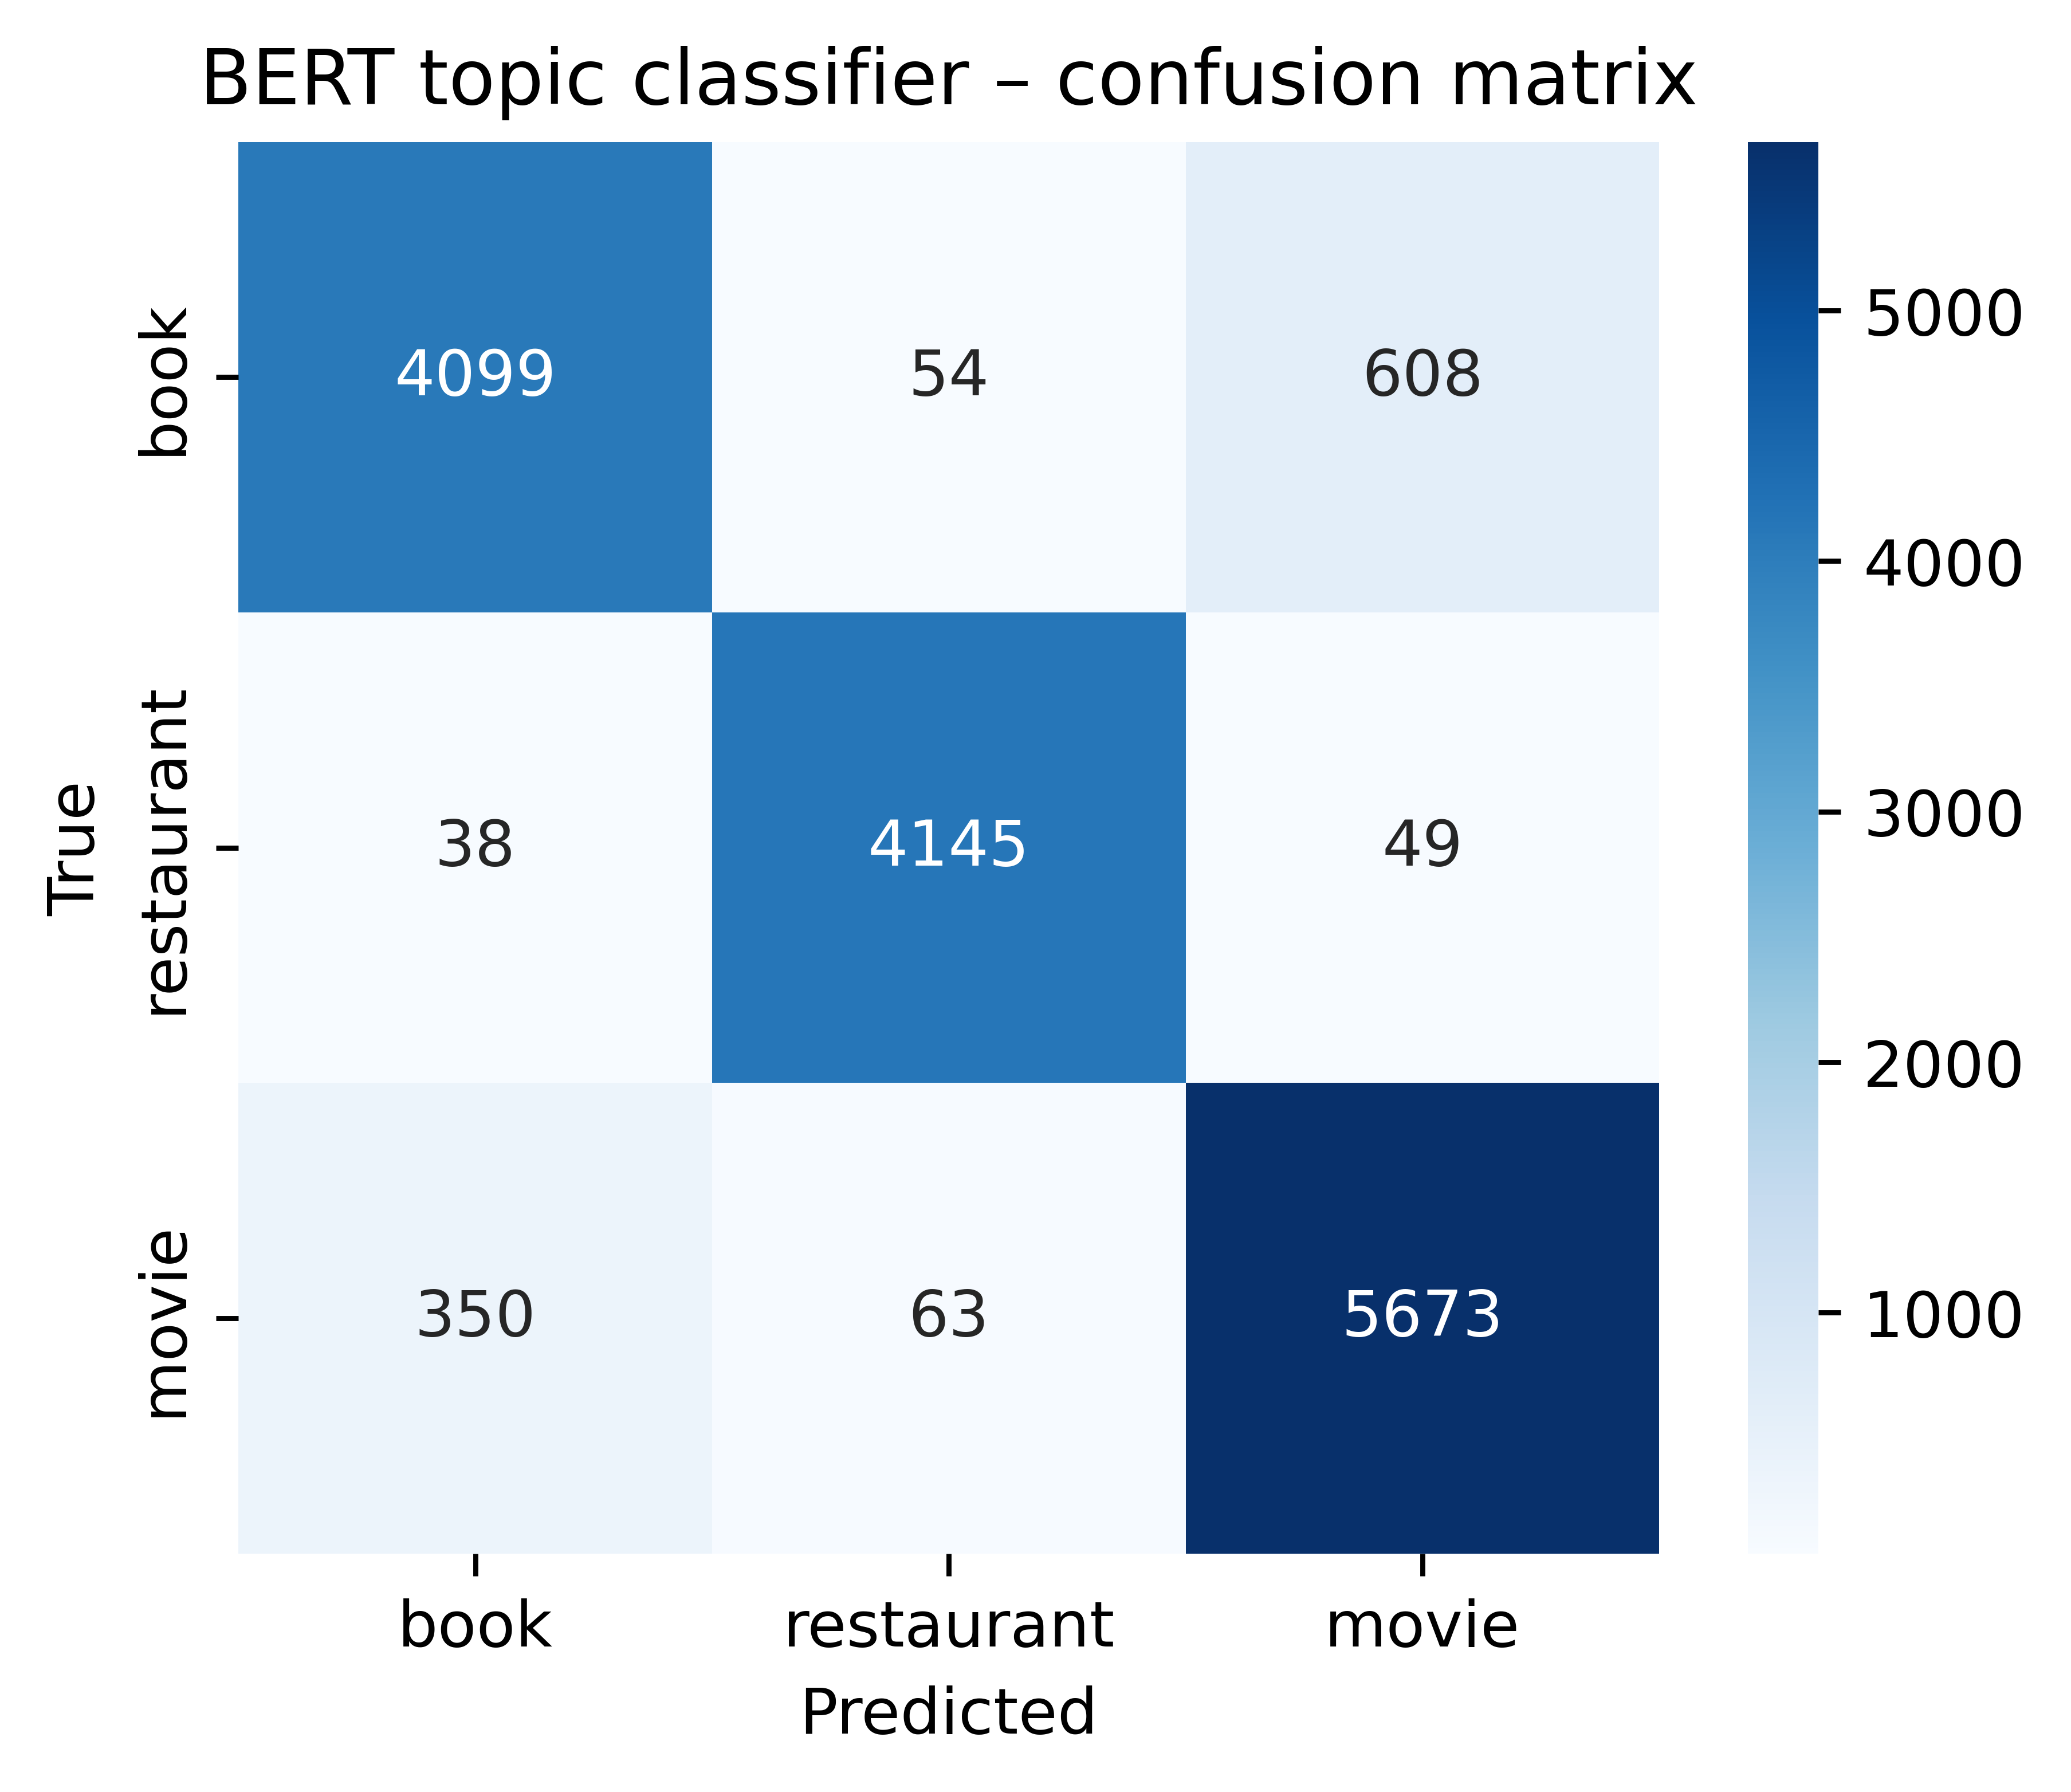

In [ ]:
print(classification_report(test["labels"], test["predicted"], digits=3))

cm = sklearn.metrics.confusion_matrix(test["labels"], test["predicted"])
cm_df = pd.DataFrame(
    cm,
    index=[inverse_label_map[i] for i in range(3)],
    columns=[inverse_label_map[i] for i in range(3)]
)

plt.figure(figsize=(5, 4), dpi=800)
sn.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("BERT topic classifier – confusion matrix")
plt.show()

### 3. Evaluating on the test set

#### 3.1 Loading and preprocessing the test set

In [24]:
test_path = "Sentiment-topic-test.tsv"
test_df = pd.read_csv(test_path, sep="\t")

test_df = test_df.dropna(subset=["text", "topic"])
test_df = test_df[test_df["topic"].isin(["book", "movie", "restaurant"])]

test_df["text"] = test_df["text"].astype(str).str.lower()
test_df["text"] = test_df["text"].apply(lambda t: re.sub(r"[^\w\s]", " ", t))
test_df["text"] = test_df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

print(test_df["topic"].value_counts())
test_df.sample(5)

topic
movie         5
restaurant    3
book          2
Name: count, dtype: int64


,sentence id,text,sentiment,topic
1,1,all the new york university students love this...,positive,restaurant
6,6,my husband and i moved to amsterdam 6 years ag...,positive,restaurant
3,3,in conclusion my review of this book would be ...,positive,book
9,9,i always have loved english novels but i just ...,negative,book
7,7,dame maggie smith performed her role excellent...,positive,movie


#### 3.2 Evaluating LDA model on the test set

In [25]:
lda_to_topic = {
    2: "movie",
    0: "book",
    1: "restaurant",
}

                                                text       topic  \
0  it took eight years for warner brothers to rec...       movie   
1  all the new york university students love this...  restaurant   
2  this italian place is really trendy but they h...  restaurant   
3  in conclusion my review of this book would be ...        book   
4  the story of this movie is focused on carl bra...       movie   

   lda_topic_idx lda_topic_pred  
0              2          movie  
1              2          movie  
2              1     restaurant  
3              0           book  
4              2          movie  

LDA classification report:
              precision    recall  f1-score   support

        book      0.500     1.000     0.667         2
       movie      0.750     0.600     0.667         5
  restaurant      1.000     0.667     0.800         3

    accuracy                          0.700        10
   macro avg      0.750     0.756     0.711        10
weighted avg      0.775     0.700

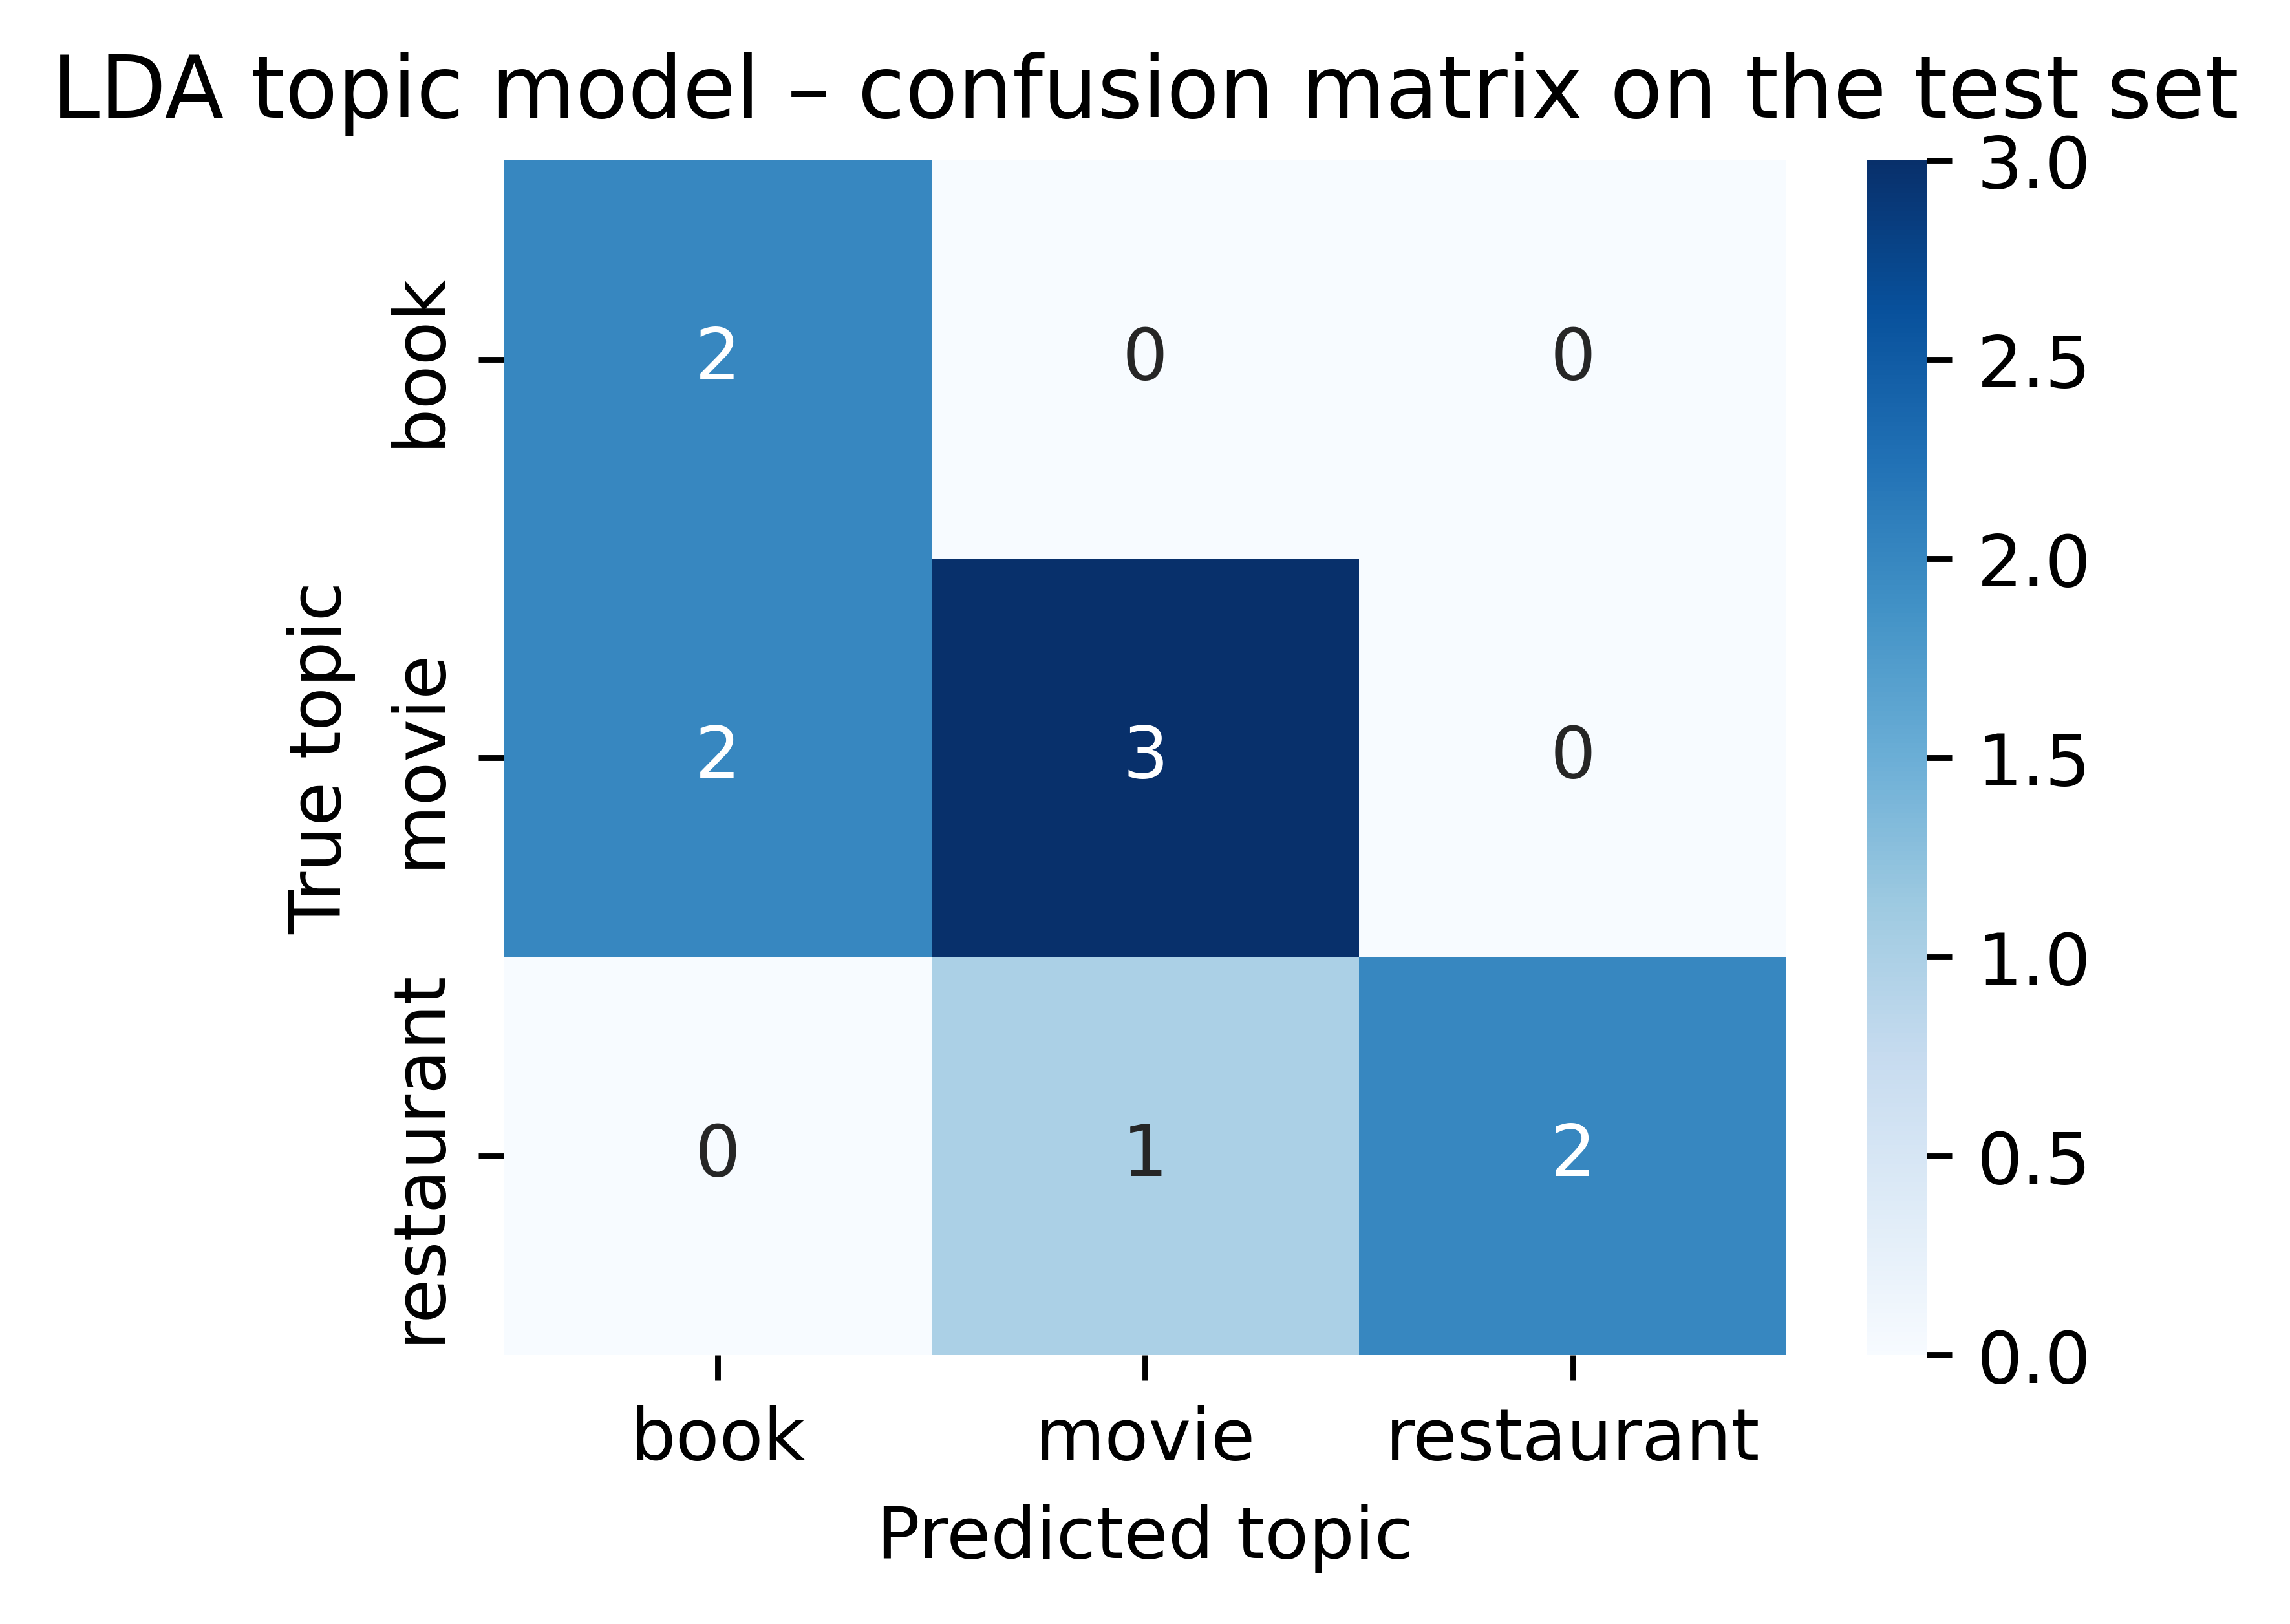

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

test_texts = test_df["text"].astype(str).tolist()

X_test_lda = vectorizer.transform(test_texts)

test_topic_dist = lda.transform(X_test_lda)
test_lda_idx = test_topic_dist.argmax(axis=1)

lda_to_topic = {
    2: "movie",
    0: "book",
    1: "restaurant",
}

test_df["lda_topic_idx"] = test_lda_idx
test_df["lda_topic_pred"] = test_df["lda_topic_idx"].map(lda_to_topic)

print(test_df[["text", "topic", "lda_topic_idx", "lda_topic_pred"]].head())

print("\nLDA classification report:")
print(classification_report(test_df["topic"], test_df["lda_topic_pred"], digits=3))

lda_cm = confusion_matrix(test_df["topic"], test_df["lda_topic_pred"], labels=["book", "movie", "restaurant"])
lda_cm_df = pd.DataFrame(lda_cm, index=["book", "movie", "restaurant"], columns=["book", "movie", "restaurant"])

plt.figure(figsize=(4, 3), dpi=800)
sn.heatmap(lda_cm_df, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True topic")
plt.xlabel("Predicted topic")
plt.title("LDA topic model – confusion matrix on the test set")
plt.show()

#### 3.3 Evaluating BERT on the test set

0it [00:00, ?it/s]

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


                                                text       topic  labels  \
0  it took eight years for warner brothers to rec...       movie       2   
1  all the new york university students love this...  restaurant       1   
2  this italian place is really trendy but they h...  restaurant       1   
3  in conclusion my review of this book would be ...        book       0   
4  the story of this movie is focused on carl bra...       movie       2   

   predicted  
0          2  
1          1  
2          1  
3          0  
4          2  

BERT classification report:
              precision    recall  f1-score   support

        book      1.000     1.000     1.000         2
       movie      1.000     1.000     1.000         3
  restaurant      1.000     1.000     1.000         5

    accuracy                          1.000        10
   macro avg      1.000     1.000     1.000        10
weighted avg      1.000     1.000     1.000        10



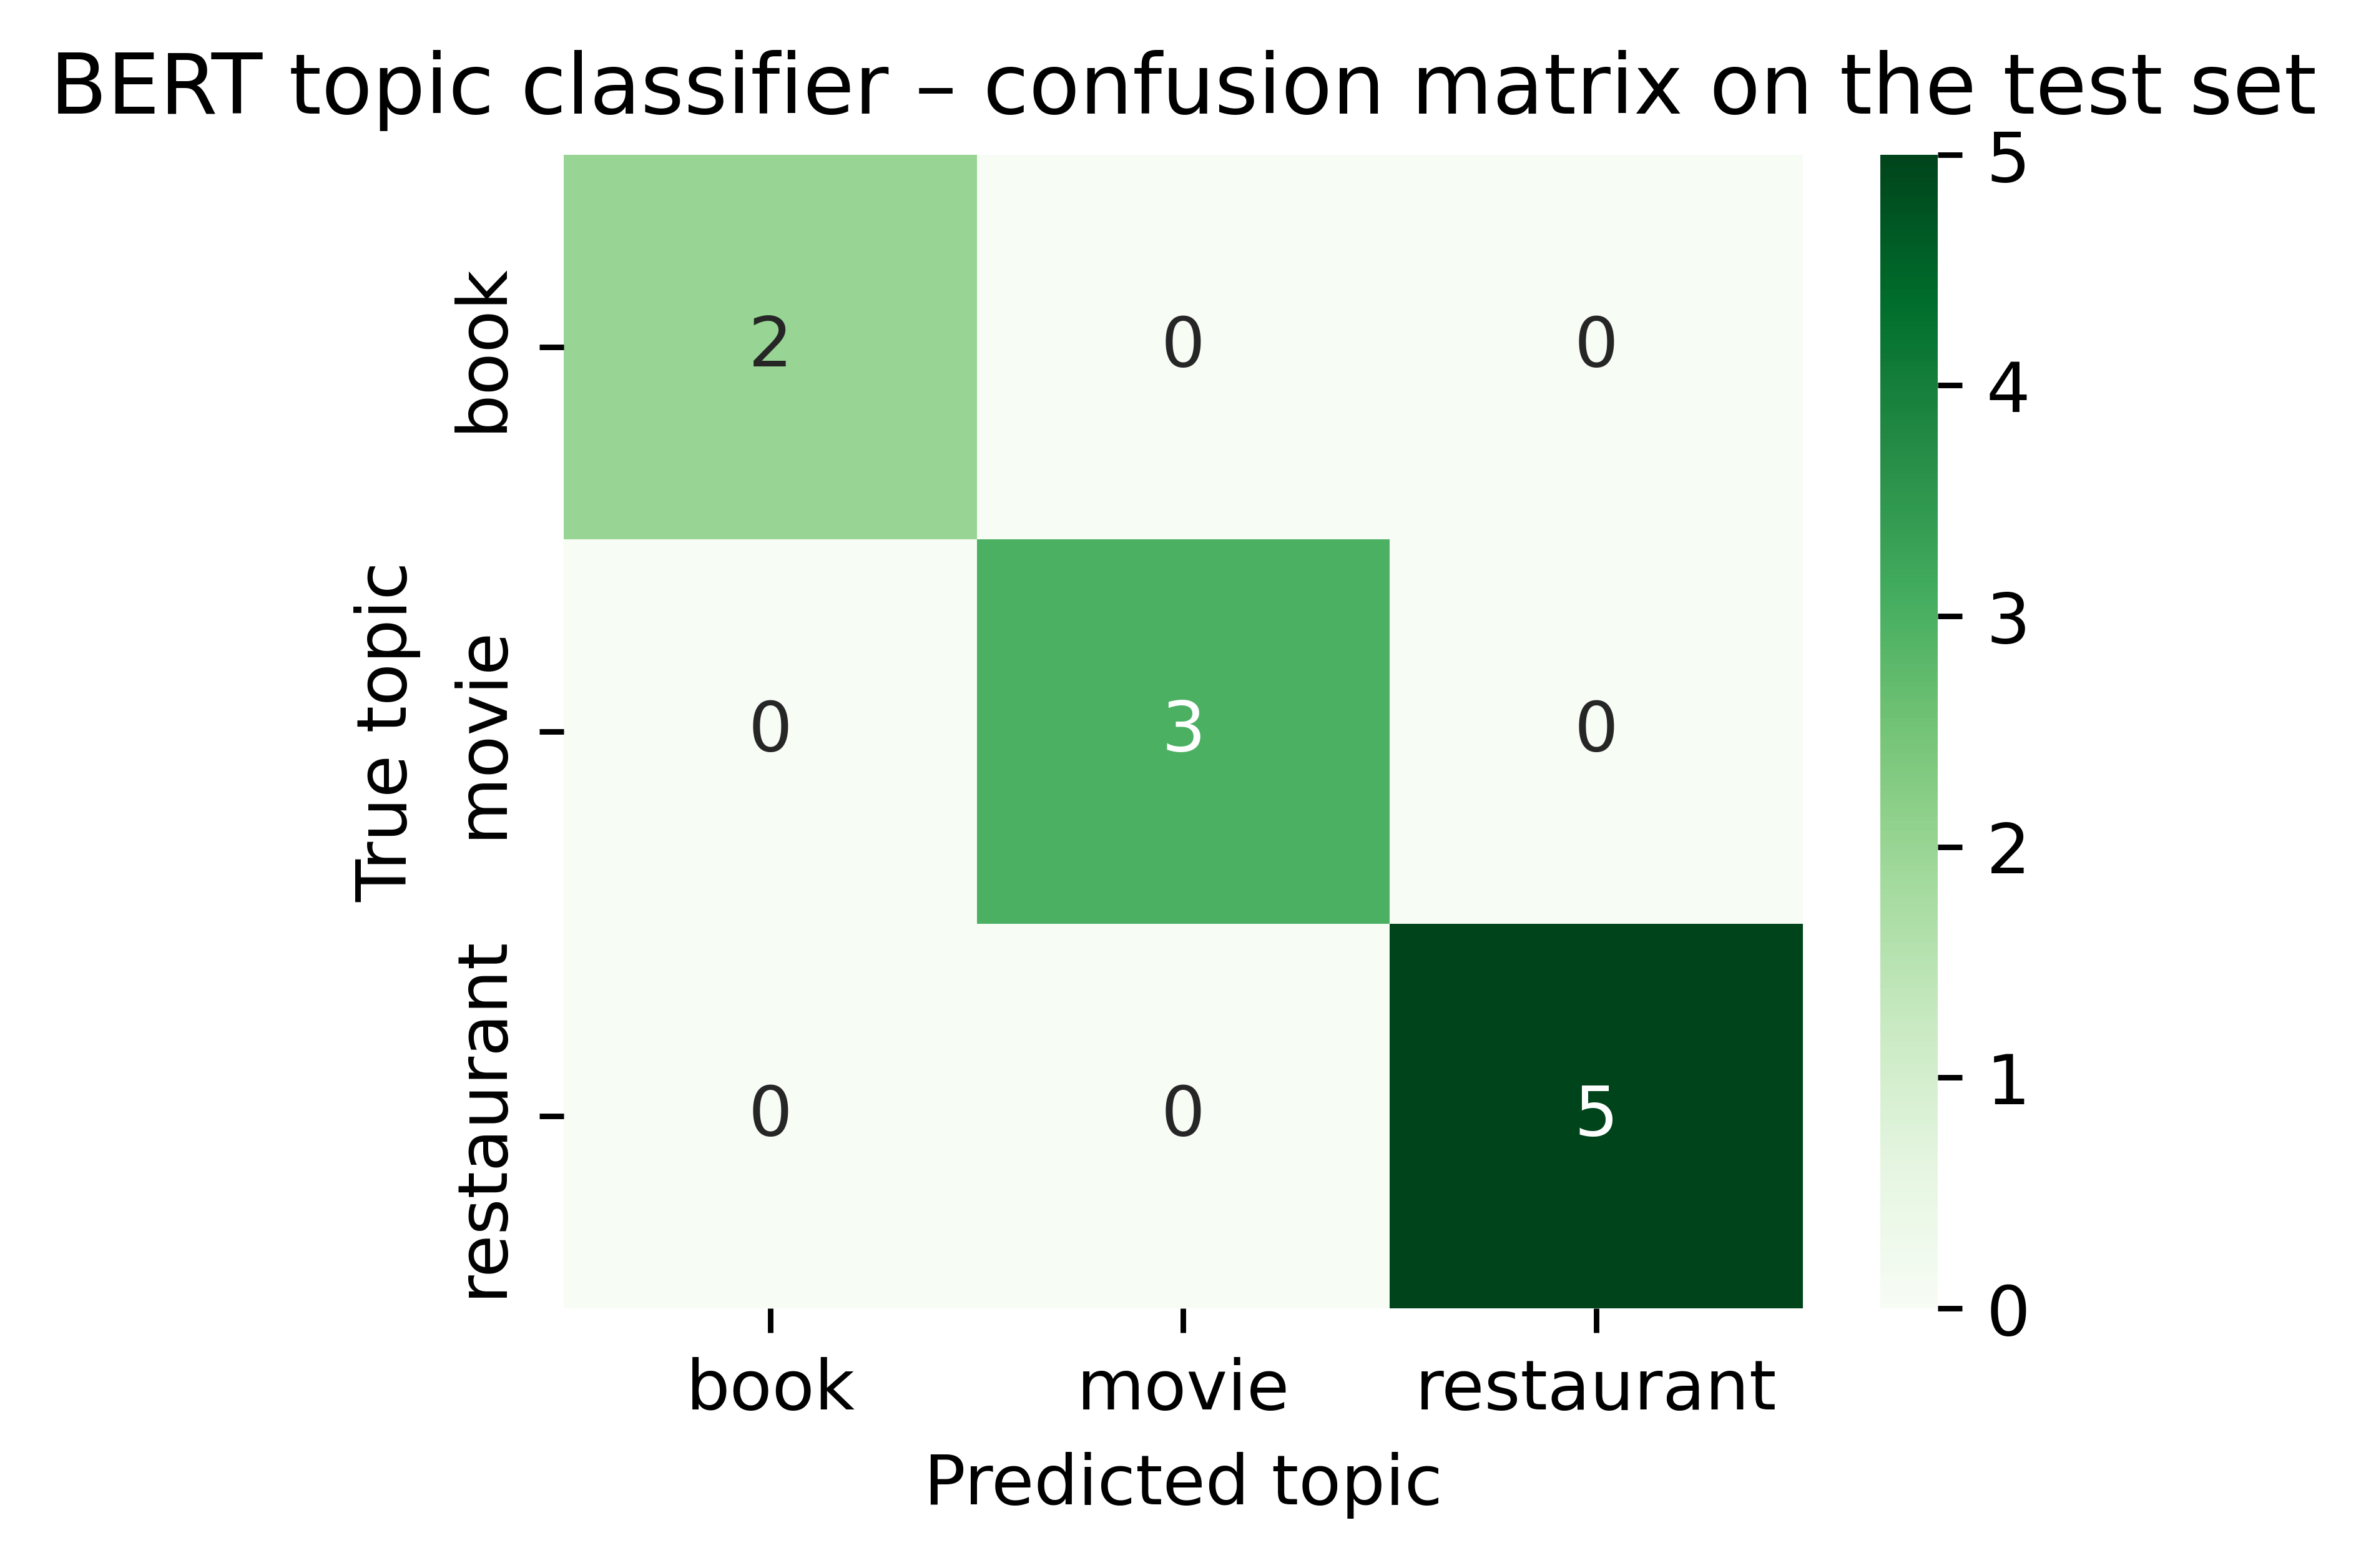

In [ ]:
label_map = {"book": 0, "movie": 2, "restaurant": 1}
inverse_label_map = {v: k for k, v in label_map.items()}

test_df_bert = test_df.copy()
test_df_bert["labels"] = test_df_bert["topic"].map(label_map)

test_df_bert = test_df_bert.dropna(subset=["text", "labels"])

pred_labels, pred_probs = model.predict(test_df_bert["text"].tolist())
test_df_bert["predicted"] = pred_labels

print(test_df_bert[["text", "topic", "labels", "predicted"]].head())

print("\nBERT classification report:")
print(classification_report(test_df_bert["labels"], test_df_bert["predicted"], target_names=["book", "movie", "restaurant"], digits=3))

bert_cm = confusion_matrix(test_df_bert["labels"], test_df_bert["predicted"])
bert_cm_df = pd.DataFrame(
    bert_cm,
    index=["book", "movie", "restaurant"],
    columns=["book", "movie", "restaurant"],
)

plt.figure(figsize=(4, 3), dpi=800)
sn.heatmap(bert_cm_df, annot=True, fmt="d", cmap="Greens")
plt.ylabel("True topic")
plt.xlabel("Predicted topic")
plt.title("BERT topic classifier – confusion matrix on the test set")
plt.show()

### Experiments with hyperparameters of LDA model

In [30]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score


# ---------- helper: preprocessing with length filters ----------

def preprocess_train_df(df, min_words=None, max_words=None):
    df = df.dropna(subset=["text", "topic"])
    df = df[df["topic"].isin(["book", "movie", "restaurant"])]
    df = df.copy()
    df["text"] = df["text"].astype(str).str.lower()
    df["text"] = df["text"].apply(lambda t: re.sub(r"[^\w\s]", " ", t))
    df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["word_count"] = df["text"].str.split().str.len()
    if min_words is not None:
        df = df[df["word_count"] > min_words]
    if max_words is not None:
        df = df[df["word_count"] < max_words]
    df = df.drop(columns=["word_count"])
    return df


def preprocess_test_df(df):
    df = df.dropna(subset=["text", "topic"])
    df = df[df["topic"].isin(["book", "movie", "restaurant"])]
    df = df.copy()
    df["text"] = df["text"].astype(str).str.lower()
    df["text"] = df["text"].apply(lambda t: re.sub(r"[^\w\s]", " ", t))
    df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    return df


# ---------- load train and external test ----------

train_csv = "unified_sentiment_topic_sentences.csv"
test_tsv = "Sentiment-topic-test.tsv"

df_train_raw = pd.read_csv(train_csv)
df_test_raw = pd.read_csv(test_tsv, sep="\t")

# ---------- define experimental settings ----------

vectorizer_settings = {
    "bow": CountVectorizer,
    "tfidf": TfidfVectorizer,
}

length_settings = [
    ("len>10",   {"min_words": 10, "max_words": None}),
    ("len>20",   {"min_words": 20, "max_words": None}),
    ("len>20<60",{"min_words": 20, "max_words": 60}),
    ("no_limit", {"min_words": None, "max_words": None}),
]

lda_to_topic = {
    2: "movie",
    0: "book",
    1: "restaurant",
}


# ---------- experiment loop ----------

results = []

for vec_name, VecClass in vectorizer_settings.items():
    for len_name, len_params in length_settings:
        df_train = preprocess_train_df(df_train_raw, **len_params)
        df_test = preprocess_test_df(df_test_raw)

        if df_train.empty or df_test.empty:
            results.append({
                "vectorizer": vec_name,
                "length_setting": len_name,
                "train_size": len(df_train),
                "test_size": len(df_test),
                "train_accuracy": np.nan,
                "test_accuracy": np.nan,
            })
            continue

        texts_train = df_train["text"].tolist()
        texts_test = df_test["text"].tolist()

        vectorizer = VecClass(
            max_df=0.95,
            min_df=2,
            max_features=5000,
            stop_words="english"
        )

        X_train = vectorizer.fit_transform(texts_train)
        X_test = vectorizer.transform(texts_test)

        lda = LatentDirichletAllocation(
            n_components=3,
            max_iter=10,
            learning_method="online",
            learning_offset=50.,
            random_state=0,
        )
        lda.fit(X_train)

        train_topic_dist = lda.transform(X_train)
        train_lda_idx = train_topic_dist.argmax(axis=1)
        df_train["lda_topic_idx"] = train_lda_idx
        df_train["lda_topic_pred"] = df_train["lda_topic_idx"].map(lda_to_topic)

        train_acc = accuracy_score(df_train["topic"], df_train["lda_topic_pred"])

        test_topic_dist = lda.transform(X_test)
        test_lda_idx = test_topic_dist.argmax(axis=1)
        df_test["lda_topic_idx"] = test_lda_idx
        df_test["lda_topic_pred"] = df_test["lda_topic_idx"].map(lda_to_topic)

        test_acc = accuracy_score(df_test["topic"], df_test["lda_topic_pred"])

        results.append({
            "vectorizer": vec_name,
            "length_setting": len_name,
            "train_size": len(df_train),
            "test_size": len(df_test),
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
        })

results_df = pd.DataFrame(results)
print(results_df)

  vectorizer length_setting  train_size  test_size  train_accuracy  \
0        bow         len>10      154762         10        0.630103   
1        bow         len>20       68685         10        0.489845   
2        bow      len>20<60       66100         10        0.630121   
3        bow       no_limit      226575         10        0.121801   
4      tfidf         len>10      154762         10        0.573248   
5      tfidf         len>20       68685         10        0.279916   
6      tfidf      len>20<60       66100         10        0.501725   
7      tfidf       no_limit      226575         10        0.260258   

   test_accuracy  
0            0.5  
1            0.5  
2            0.9  
3            0.2  
4            0.4  
5            0.2  
6            0.6  
7            0.1  


## I noticed that the lda_to_topic may each time be different >> the results are not valid!